<a href="https://colab.research.google.com/github/SantiaGaGo/Financiero---UniAndes-TodosALaU/blob/main/Ej_MediasBandasOsciladores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install yfinance

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 62 kB 1.2 MB/s 
  Attempting uninstall: requests
    Found existing installation: requests 2.23.0
    Uninstalling requests-2.23.0:
      Successfully uninstalled requests-2.23.0


In [ ]:
pip install ta

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Created wheel for ta: filename=ta-0.10.2-py3-none-any.whl size=29104 sha256=e837d69b6bf49441abaf25e3482f6032a860e4cab90486d48eb44872d6b3a3ff
  Stored in directory: /root/.cache/pip/wheels/31/31/f1/f2ff471bbc5b84a4b973698ceecdd453ae043971791adc3431
Successfully built ta


In [ ]:
#librerias y manejo de tablas
import yfinance as yfin
import pandas as pd
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
import ta

In [ ]:
df= yfin.download('BTC-USD', start= '2020-07-01', end = '2021-07-01')
df

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-07-01 00:00:00+00:00,9145.985352,9309.754883,9104.735352,9228.325195,9228.325195,15971550355
2020-07-02 00:00:00+00:00,9231.139648,9274.962891,9036.623047,9123.410156,9123.410156,16338916796
2020-07-03 00:00:00+00:00,9124.842773,9202.344727,9058.794922,9087.303711,9087.303711,13078970999
2020-07-04 00:00:00+00:00,9084.233398,9183.295898,9053.629883,9132.488281,9132.488281,12290528515
2020-07-05 00:00:00+00:00,9126.090820,9162.183594,8977.015625,9073.942383,9073.942383,12903406143
...,...,...,...,...,...,...
2021-06-26 00:00:00+00:00,31594.664062,32637.587891,30184.501953,32186.277344,32186.277344,38585385521
2021-06-27 00:00:00+00:00,32287.523438,34656.128906,32071.757812,34649.644531,34649.644531,35511640894
2021-06-28 00:00:00+00:00,34679.121094,35219.890625,33902.074219,34434.335938,34434.335938,33892523752


In [ ]:
#SMA 5 dias
df['SMA_short']=df['Adj Close'].rolling(window=5).mean()

#SMA 20 dias
df['SMA_long']=df['Adj Close'].rolling(window=20).mean()

df

,Open,High,Low,Close,Adj Close,Volume,SMA_short,SMA_long
Date,,,,,,,,
2020-07-01 00:00:00+00:00,9145.985352,9309.754883,9104.735352,9228.325195,9228.325195,15971550355,NaN,NaN
2020-07-02 00:00:00+00:00,9231.139648,9274.962891,9036.623047,9123.410156,9123.410156,16338916796,NaN,NaN
2020-07-03 00:00:00+00:00,9124.842773,9202.344727,9058.794922,9087.303711,9087.303711,13078970999,NaN,NaN
2020-07-04 00:00:00+00:00,9084.233398,9183.295898,9053.629883,9132.488281,9132.488281,12290528515,NaN,NaN
2020-07-05 00:00:00+00:00,9126.090820,9162.183594,8977.015625,9073.942383,9073.942383,12903406143,9129.093945,NaN
...,...,...,...,...,...,...,...,...
2021-06-26 00:00:00+00:00,31594.664062,32637.587891,30184.501953,32186.277344,32186.277344,38585385521,32943.036328,35679.221680
2021-06-27 00:00:00+00:00,32287.523438,34656.128906,32071.757812,34649.644531,34649.644531,35511640894,33371.833203,35733.668555
2021-06-28 00:00:00+00:00,34679.121094,35219.890625,33902.074219,34434.335938,34434.335938,33892523752,33514.094922,35781.753711


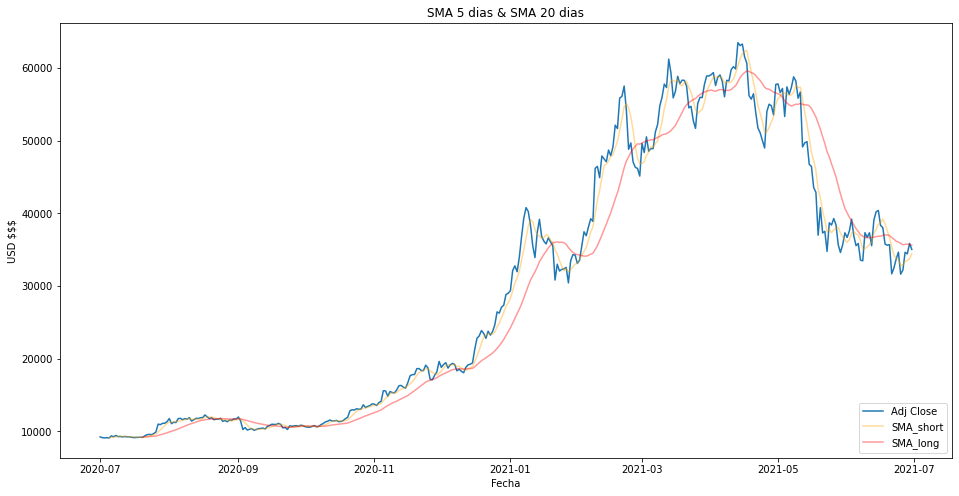

In [ ]:
plt.figure(figsize=(16,8))
plt.title('SMA 5 dias & SMA 20 dias')
plt.plot(df['Adj Close'])
plt.plot(df['SMA_short'], color ='orange', alpha=0.4)
plt.plot(df['SMA_long'], color ='red',alpha=0.4)
plt.xlabel('Fecha')
plt.ylabel('USD $$$')
plt.legend(['Adj Close', 'SMA_short','SMA_long'], loc='lower right')
plt.show()

In [ ]:
#EMA 5 dias
df['EMA_short']= df['Adj Close'].ewm(span=5, adjust=False).mean()

#EMA 20 dias
df['EMA_long']= df['Adj Close'].ewm(span=20, adjust=False).mean()

df

,Open,High,Low,Close,Adj Close,Volume,SMA_short,SMA_long,EMA_short,EMA_long
Date,,,,,,,,,,
2020-07-01 00:00:00+00:00,9145.985352,9309.754883,9104.735352,9228.325195,9228.325195,15971550355,NaN,NaN,9228.325195,9228.325195
2020-07-02 00:00:00+00:00,9231.139648,9274.962891,9036.623047,9123.410156,9123.410156,16338916796,NaN,NaN,9193.353516,9218.333287
2020-07-03 00:00:00+00:00,9124.842773,9202.344727,9058.794922,9087.303711,9087.303711,13078970999,NaN,NaN,9158.003581,9205.854280
2020-07-04 00:00:00+00:00,9084.233398,9183.295898,9053.629883,9132.488281,9132.488281,12290528515,NaN,NaN,9149.498481,9198.867042
2020-07-05 00:00:00+00:00,9126.090820,9162.183594,8977.015625,9073.942383,9073.942383,12903406143,9129.093945,NaN,9124.313115,9186.969455
...,...,...,...,...,...,...,...,...,...,...
2021-06-26 00:00:00+00:00,31594.664062,32637.587891,30184.501953,32186.277344,32186.277344,38585385521,32943.036328,35679.221680,32962.413029,35385.003934
2021-06-27 00:00:00+00:00,32287.523438,34656.128906,32071.757812,34649.644531,34649.644531,35511640894,33371.833203,35733.668555,33524.823530,35314.969706
2021-06-28 00:00:00+00:00,34679.121094,35219.890625,33902.074219,34434.335938,34434.335938,33892523752,33514.094922,35781.753711,33827.994332,35231.099823


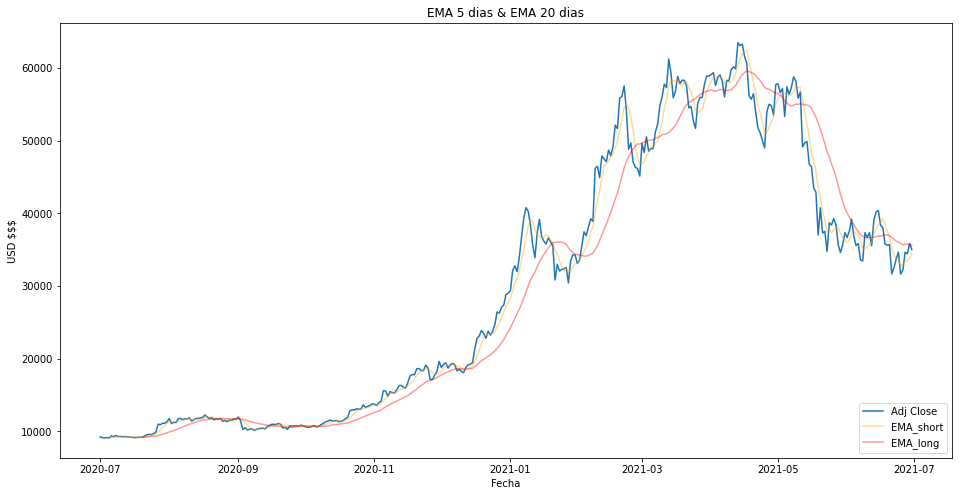

In [ ]:
plt.figure(figsize=(16,8))
plt.title('EMA 5 dias & EMA 20 dias')
plt.plot(df['Adj Close'])
plt.plot(df['SMA_short'], color ='orange', alpha=0.4)
plt.plot(df['SMA_long'], color ='red',alpha=0.4)
plt.xlabel('Fecha')
plt.ylabel('USD $$$')
plt.legend(['Adj Close', 'EMA_short','EMA_long'], loc='lower right')
plt.show()

In [ ]:
#bandas de bollinger
bb= ta.volatility.BollingerBands(close=df['Close'], window=20, window_dev=2)

df['BOL_M']= bb.bollinger_mavg()
df['BOL_U']= bb.bollinger_hband()
df['BOL_D']= bb.bollinger_lband()

df

,Open,High,Low,Close,Adj Close,Volume,SMA_short,SMA_long,EMA_short,EMA_long,BOL_M,BOL_U,BOL_D
Date,,,,,,,,,,,,,
2020-07-01 00:00:00+00:00,9145.985352,9309.754883,9104.735352,9228.325195,9228.325195,15971550355,NaN,NaN,9228.325195,9228.325195,NaN,NaN,NaN
2020-07-02 00:00:00+00:00,9231.139648,9274.962891,9036.623047,9123.410156,9123.410156,16338916796,NaN,NaN,9193.353516,9218.333287,NaN,NaN,NaN
2020-07-03 00:00:00+00:00,9124.842773,9202.344727,9058.794922,9087.303711,9087.303711,13078970999,NaN,NaN,9158.003581,9205.854280,NaN,NaN,NaN
2020-07-04 00:00:00+00:00,9084.233398,9183.295898,9053.629883,9132.488281,9132.488281,12290528515,NaN,NaN,9149.498481,9198.867042,NaN,NaN,NaN
2020-07-05 00:00:00+00:00,9126.090820,9162.183594,8977.015625,9073.942383,9073.942383,12903406143,9129.093945,NaN,9124.313115,9186.969455,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-06-26 00:00:00+00:00,31594.664062,32637.587891,30184.501953,32186.277344,32186.277344,38585385521,32943.036328,35679.221680,32962.413029,35385.003934,35679.221680,41023.920892,30334.522467
2021-06-27 00:00:00+00:00,32287.523438,34656.128906,32071.757812,34649.644531,34649.644531,35511640894,33371.833203,35733.668555,33524.823530,35314.969706,35733.668555,41012.715513,30454.621597
2021-06-28 00:00:00+00:00,34679.121094,35219.890625,33902.074219,34434.335938,34434.335938,33892523752,33514.094922,35781.753711,33827.994332,35231.099823,35781.753711,40994.649699,30568.857723


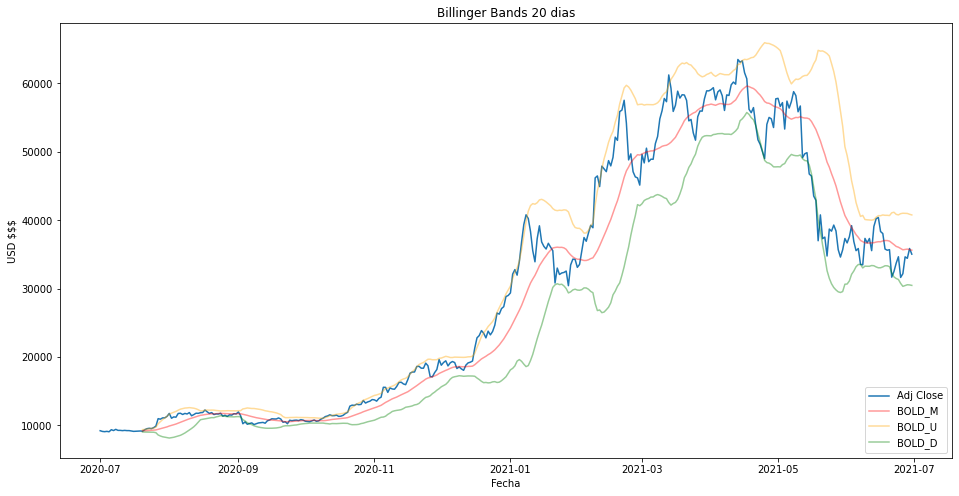

In [ ]:
plt.figure(figsize=(16,8))
plt.title('Billinger Bands 20 dias')
plt.plot(df['Adj Close'])
plt.plot(df['BOL_M'], color ='red', alpha=0.4)
plt.plot(df['BOL_U'], color ='orange', alpha=0.4)
plt.plot(df['BOL_D'], color ='green', alpha=0.4)
plt.xlabel('Fecha')
plt.ylabel('USD $$$')
plt.legend(['Adj Close', 'BOLD_M','BOLD_U','BOLD_D'], loc='lower right')
plt.show()

In [ ]:
#Media movil de convergencia-divergencia (MACD)
df['MACD']= ta.trend.MACD(close=df['Close'], window_fast=12, window_slow=26).macd()
df

,Open,High,Low,Close,Adj Close,Volume,SMA_short,SMA_long,EMA_short,EMA_long,BOL_M,BOL_U,BOL_D,MACD
Date,,,,,,,,,,,,,,
2020-07-01 00:00:00+00:00,9145.985352,9309.754883,9104.735352,9228.325195,9228.325195,15971550355,NaN,NaN,9228.325195,9228.325195,NaN,NaN,NaN,NaN
2020-07-02 00:00:00+00:00,9231.139648,9274.962891,9036.623047,9123.410156,9123.410156,16338916796,NaN,NaN,9193.353516,9218.333287,NaN,NaN,NaN,NaN
2020-07-03 00:00:00+00:00,9124.842773,9202.344727,9058.794922,9087.303711,9087.303711,13078970999,NaN,NaN,9158.003581,9205.854280,NaN,NaN,NaN,NaN
2020-07-04 00:00:00+00:00,9084.233398,9183.295898,9053.629883,9132.488281,9132.488281,12290528515,NaN,NaN,9149.498481,9198.867042,NaN,NaN,NaN,NaN
2020-07-05 00:00:00+00:00,9126.090820,9162.183594,8977.015625,9073.942383,9073.942383,12903406143,9129.093945,NaN,9124.313115,9186.969455,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-06-26 00:00:00+00:00,31594.664062,32637.587891,30184.501953,32186.277344,32186.277344,38585385521,32943.036328,35679.221680,32962.413029,35385.003934,35679.221680,41023.920892,30334.522467,-1901.141713
2021-06-27 00:00:00+00:00,32287.523438,34656.128906,32071.757812,34649.644531,34649.644531,35511640894,33371.833203,35733.668555,33524.823530,35314.969706,35733.668555,41012.715513,30454.621597,-1733.088279
2021-06-28 00:00:00+00:00,34679.121094,35219.890625,33902.074219,34434.335938,34434.335938,33892523752,33514.094922,35781.753711,33827.994332,35231.099823,35781.753711,40994.649699,30568.857723,-1598.847804


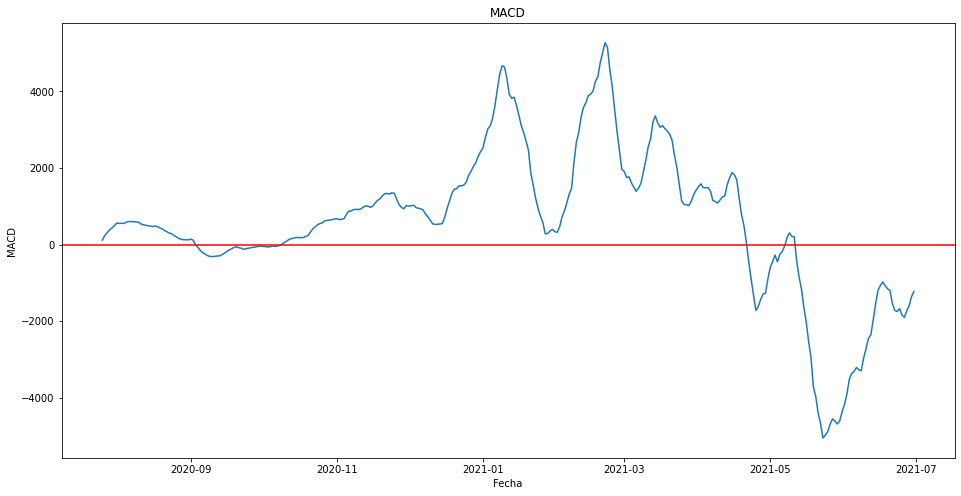

In [ ]:
plt.figure(figsize=(16,8))
plt.title('MACD')
plt.plot(df['MACD'])
plt.xlabel('Fecha')
plt.ylabel('MACD')
plt.axhline(y=0, color='red')
plt.show()

In [ ]:
#retrocesod de fibonacci
max_p=df['Close'].max()
min_p=df['Close'].min()

dif_p=max_p-min_p

r_fibo=np.array([0.236, 0.382, 0.5, 0.618])
levels=max_p-dif_p*r_fibo

levels

array([50658.09157422, 42711.38243555, 36288.69970703, 29866.01697852])

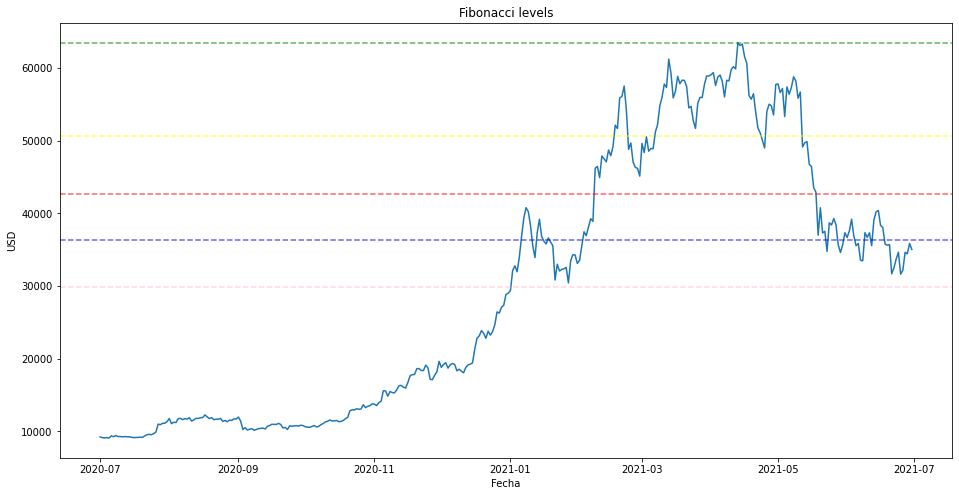

In [ ]:
plt.figure(figsize=(16,8))
plt.title('Fibonacci levels')
plt.plot(df['Close'])
plt.xlabel('Fecha')
plt.ylabel('USD')
plt.axhline(y=max_p, color='green', linestyle='--',alpha=0.6)

plt.axhline(y=levels[0], color='yellow', linestyle='--',alpha=0.6)
plt.axhline(y=levels[1], color='red', linestyle='--',alpha=0.6)
plt.axhline(y=levels[2], color='blue', linestyle='--',alpha=0.6)
plt.axhline(y=levels[3], color='pink', linestyle='--',alpha=0.6)

plt.show()